In [1]:
# 2025.12.01 Ensemble Set No 1 + GB 돌리기
# SMOTE 오버샘플링 적용 -> Catboost + XGBoost + LightGBM + GradientBoost 4개 스태킹(부스팅 계열)

In [2]:
import sys

project_root = 'c:/big20/git/big20-ML-project2-team3/CreditCardFraud'

# sys.path에 추가 (모듈 import용)
if project_root not in sys.path:
    sys.path.insert(0, project_root)

In [3]:
import os

import time
import pandas as pd
import numpy  as np
import matplotlib.pyplot as plt
import seaborn as sns


import warnings
warnings.filterwarnings('ignore')

module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.metrics         import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics         import classification_report
from sklearn.metrics         import roc_auc_score
from sklearn.metrics         import precision_recall_curve, classification_report
from sklearn.datasets        import make_classification
from sklearn.preprocessing   import RobustScaler

# Model import
from sklearn.tree           import DecisionTreeClassifier
from sklearn.ensemble       import StackingClassifier
from sklearn.ensemble       import RandomForestClassifier
from sklearn.ensemble       import GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model   import LogisticRegression
from sklearn.linear_model   import LinearRegression
from sklearn.linear_model   import SGDClassifier
from sklearn.svm            import SVC
from sklearn.svm            import LinearSVC
from xgboost                import XGBClassifier
from xgboost                import plot_importance
from lightgbm               import LGBMClassifier
from catboost               import CatBoostClassifier
from sklearn.ensemble       import HistGradientBoostingClassifier
from sklearn.calibration    import CalibratedClassifierCV # stacking시 LSVC 에러용

# hyperopt 용
from hyperopt               import hp

# 사용자 Functions import
import HyperParams          as HP 
import utils.data_sampling  as ds 

import importlib

from utils import user_utils
importlib.reload(user_utils)

from utils import user_utils    as uu
from utils import preprocessing as pp
from utils import data_sampling as ds
from utils import model_utils   as mu
from utils import modeling      as mo

from utils.hyperopt_search import hyperopt_search, train_and_evaluate

In [4]:
# -------------------------------------------------------
# 🔷 모델 생성 함수 (HyperOpt 파라미터 자동 적용)
# -------------------------------------------------------

def get_models():
    models = {
        "cat": CatBoostClassifier(**HP.cb_best_params),
        "lgbm": LGBMClassifier(**HP.lgbm_best_param2),
        "lr": LogisticRegression(**HP.lr_best_params),
        "xgb": XGBClassifier(**HP.xgb_best_params, eval_metric='logloss'),
        "gb": GradientBoostingClassifier(**HP.gb_best_params),

    }

    return models
# eof ----------------------------------------------------------------

In [5]:
# 결과받을 딕셔너리
results = {}
team_rs = 23 # 우리팀 random_state

In [6]:
#1. 데이터 로딩
raw_df = pp.ccf_load_data()

데이터 로드 성공: (284807, 31)


In [7]:
# 2. 데이터 전처리
# 2.1 Time 컬럼 삭제 , 데이터,타겟 분리
X_features, y_target = pp.split_features_target(raw_df, cols= 'Time')
X_features.shape, y_target.shape

((284807, 29), (284807,))

In [8]:
# 2.2 이상치를 경계값으로 치환
cap_X_feature = pp.cap_outliers(X_features)

In [9]:
# 2.3 학습/테스트 데이터 분리
X_train, X_test, y_train, y_test = pp.data_split(cap_X_feature, y_target)

In [10]:
# 2.4 Over Sampling 하는 경우
X_over, y_over = ds.oversampling_smote(X_train, y_train)

✅ SMOTE 오버샘플링 완료
   원본 샘플 수: 227845 (Class 0: 227451, Class 1: 394)
   샘플링 후: 454902 (Class 0: 227451, Class 1: 227451)


In [11]:
# 2.5 학습/검증 데이터 분리
X_tr, X_val, y_tr, y_val = pp.data_split(X_train, y_train, size=0.4)

In [12]:
# 2.6 Over Sampling한 경우 학습/검증 데이터 분리
X_tr_over, X_val_over, y_tr_over, y_val_over = pp.data_split(X_over, y_over, size=0.4)

In [13]:
# ======================================
# 🔷 Stacking #4: CB + XGB + LGBM + GB
# ======================================

models = get_models()

# 메타모델 (최종 분류기)
est_lr = LogisticRegression(
    penalty='l2',
    C=1.0,
    solver='liblinear',
    class_weight='balanced',
    random_state=23
)

# 베이스 모델 4개 (CatBoost, XGB, LGBM, GB)
estimators_1_3 = [
    ('cat', models['cat']),
    ('xgb', models['xgb']),
    ('lgbm', models['lgbm']),
    ('gb', models['gb'])
]

# 스태킹 앙상블
stack_1_3 = StackingClassifier(
    estimators=estimators_1_3,
    final_estimator=est_lr,
    stack_method='predict_proba',
    cv=5,
    n_jobs=-1
)

# 학습 및 평가
option_name = 'stack1_3(cat+xgb+lgbm+gb)_ho_best_SMOTE'
results = uu.get_model_train_eval(stack_1_3, option_name, X_over, X_test, y_over, y_test)


🚀 모델 학습 시작: stack1_3(cat+xgb+lgbm+gb)_ho_best_SMOTE


stack1_3(cat+xgb+lgbm+gb)_ho_best_SMOTE - 예측 중:  25%|██      | 1/4 [1:48:54<5:26:42, 6534.14s/it]/s]

[LightGBM] [Warning] min_data_in_leaf is set=25, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=25
[LightGBM] [Warning] feature_fraction is set=0.801203, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.801203
[LightGBM] [Warning] min_gain_to_split is set=0.002445, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=0.002445
[LightGBM] [Warning] lambda_l1 is set=0.512937, reg_alpha=0.548894 will be ignored. Current value: lambda_l1=0.512937
[LightGBM] [Warning] lambda_l2 is set=1.092e-07, reg_lambda=2.435e-08 will be ignored. Current value: lambda_l2=1.092e-07
[LightGBM] [Warning] bagging_fraction is set=0.825535, subsample=1.0 will be ignored. Current value: bagging_fraction=0.825535
[LightGBM] [Warning] bagging_freq is set=4, subsample_freq=0 will be ignored. Current value: bagging_freq=4
[LightGBM] [Warning] min_data_in_leaf is set=25, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=25
[LightGBM] [W

stack1_3(cat+xgb+lgbm+gb)_ho_best_SMOTE - 평가 중:  50%|████    | 2/4 [1:48:55<1:29:42, 2691.47s/it]

folder = c:\big20\git\big20-ML-project2-team3\CreditCardFraud\results
{'result_dict': {'AUC': 0.9726, '정확도': 0.99, '정밀도': 0.1331, '재현율': 0.8776, 'F1': 0.2312, 'F2': 0.4143}, '오차행렬': [[56304, 560], [12, 86]], '실행 시간': 6535.7399}

📊 Base Estimators 평가 중 (4개)...


[LightGBM] [Warning] min_data_in_leaf is set=25, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=25
[LightGBM] [Warning] feature_fraction is set=0.801203, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.801203
[LightGBM] [Warning] min_gain_to_split is set=0.002445, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=0.002445
[LightGBM] [Warning] lambda_l1 is set=0.512937, reg_alpha=0.548894 will be ignored. Current value: lambda_l1=0.512937
[LightGBM] [Warning] lambda_l2 is set=1.092e-07, reg_lambda=2.435e-08 will be ignored. Current value: lambda_l2=1.092e-07
[LightGBM] [Warning] bagging_fraction is set=0.825535, subsample=1.0 will be ignored. Current value: bagging_fraction=0.825535
[LightGBM] [Warning] bagging_freq is set=4, subsample_freq=0 will be ignored. Current value: bagging_freq=4
[LightGBM] [Warning] min_data_in_leaf is set=25, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=25
[LightGBM] [W

stack1_3(cat+xgb+lgbm+gb)_ho_best_SMOTE - 저장 중: 100%|██████████| 4/4 [1:48:57<00:00, 1634.40s/it]

✓ 모델 저장 완료: ../models\stack1_3(cat+xgb+lgbm+gb)_ho_best_SMOTE.pkl
  파일 크기: 2.77 MB

✅ 완료: stack1_3(cat+xgb+lgbm+gb)_ho_best_SMOTE (실행시간: 6535.74초)



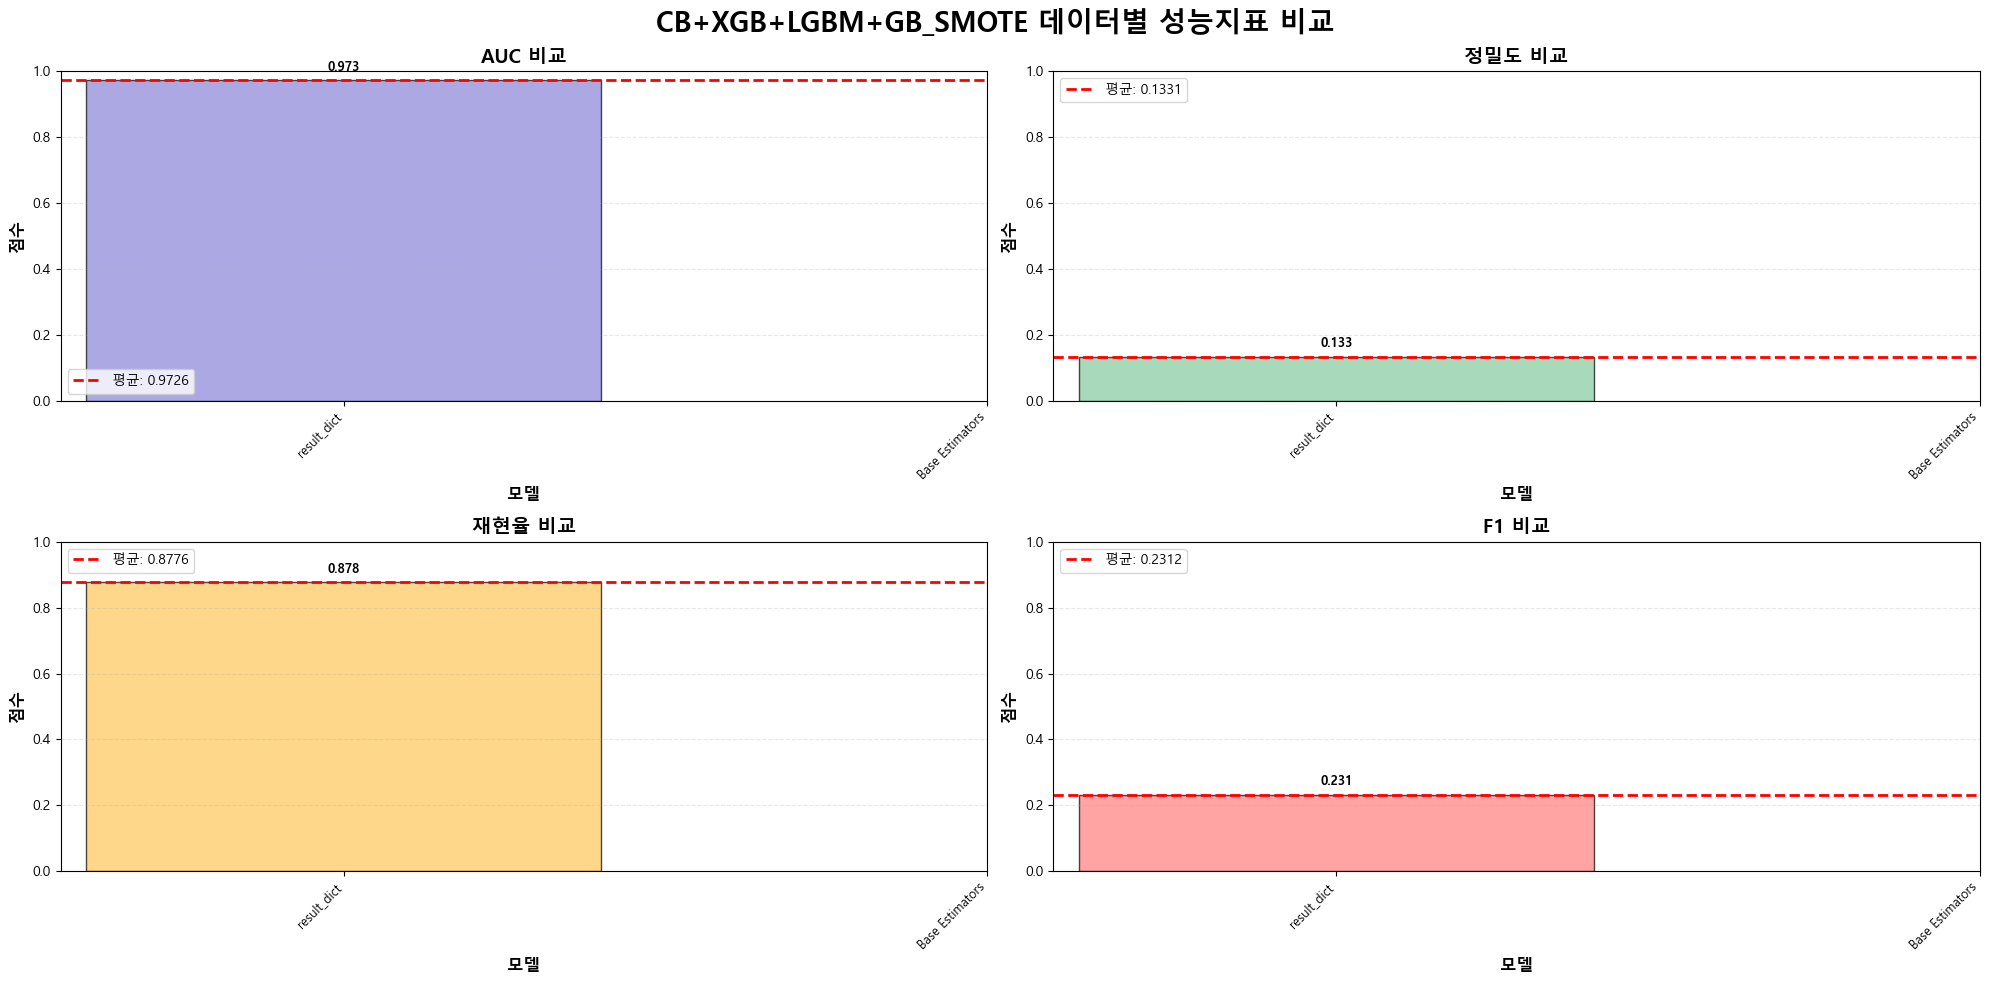


=== 지표별 통계 요약 ===

[AUC]
  최고: 0.9726 (result_dict)
  최저: 0.9726 (result_dict)
  평균: 0.9726
  표준편차: nan

[정밀도]
  최고: 0.1331 (result_dict)
  최저: 0.1331 (result_dict)
  평균: 0.1331
  표준편차: nan

[재현율]
  최고: 0.8776 (result_dict)
  최저: 0.8776 (result_dict)
  평균: 0.8776
  표준편차: nan

[F1]
  최고: 0.2312 (result_dict)
  최저: 0.2312 (result_dict)
  평균: 0.2312
  표준편차: nan


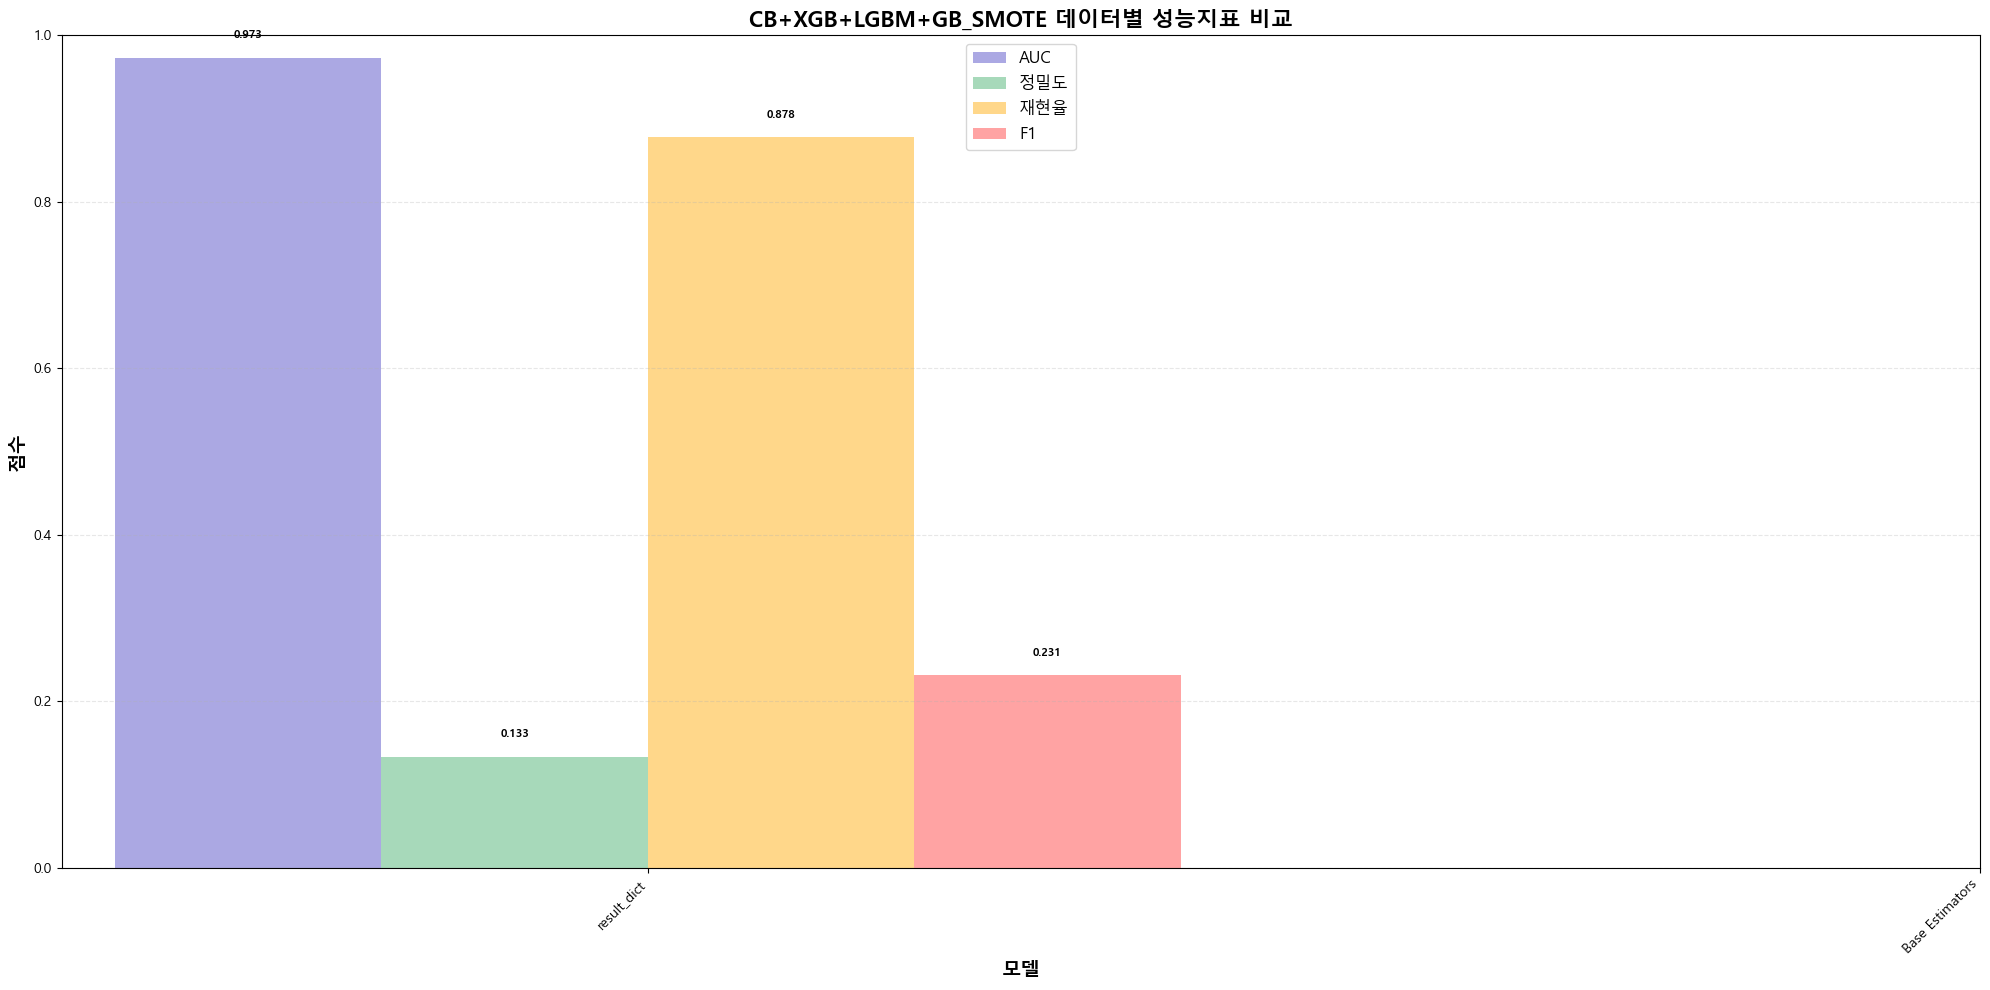


=== F1 Score 기준 상위 5개 모델 ===
[에러 발생] Column 'F1' has dtype object, cannot use method 'nlargest' with this dtype


In [15]:
# 시각화
mo.model_metrics_graph(results, 'CB+XGB+LGBM+GB_SMOTE 데이터별 성능지표 비교')